# 99,2% de los estudios miden mal el nivel del mar

383 de 386 evaluaciones de riesgo costero asumen un nivel del mar que **no coincide con la realidad**. ¿Cuánta gente se queda fuera de los cálculos?

---

**Paper:** Vetter et al. (2026) — *Nature*
**DOI:** [10.1038/s41586-026-10196-1](https://doi.org/10.1038/s41586-026-10196-1)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=5knq_zYVC04)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-11-nivel-mar-132-millones/notebook.ipynb)

## El problema que nadie vio

Cuando se estima cuánta tierra y cuántas personas están en riesgo por la subida del nivel del mar, hay que saber dos cosas: **qué tan alto está el agua** y **qué tan alto está el terreno**.

Para el terreno, se usan modelos de elevación digital (DEMs). Pero para el nivel del mar, la mayoría de los estudios usan **modelos geoide** (EGM96, EGM2008) — una aproximación matemática de la superficie del mar. Vetter y compañía revisaron 386 publicaciones de impacto costero (2009–2025) y encontraron que **casi ninguna usó mediciones reales** del nivel del mar (altimetría satelital, mareógrafos). El resultado: el mar real es más alto que el que asumen los modelos, sobre todo en el Indo-Pacífico. Y eso cambia todo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ESCENARIO_RSLR = 1       # Metros de subida relativa del nivel del mar
OFFSET_PAPER = 0.27      # Offset medio global (m) reportado en el paper (EGM96)
FUENTE = 'Fuente: Vetter et al. (2026), Nature | Datos: Supplementary Tables'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_VIOLETA = '#7C3AED'

# ── Setup ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Cargar datos ──
df_offset = pd.read_csv('datos/offset_nivel_mar.csv')
df_impacto = pd.read_csv('datos/impacto_por_region.csv')
df_lit = pd.read_csv('datos/evaluacion_literatura.csv')
df_dem = pd.read_csv('datos/impacto_por_dem.csv')

total_papers = df_lit['n_papers'].sum()
total_adecuados = df_lit['adecuados'].sum()
print(f"Papers evaluados: {total_papers}")
print(f"Con manejo adecuado de datum vertical: {total_adecuados} ({total_adecuados/total_papers*100:.1f}%)")
print(f"Regiones en offset: {len(df_offset)}")
print(f"DEMs comparados: {df_dem['dem'].nunique()}")

Papers evaluados: 386
Con manejo adecuado de datum vertical: 3 (0.8%)
Regiones en offset: 18
DEMs comparados: 4


## ¿Cuánto se equivocan?

El mar real está **más alto** que el nivel que usan los modelos. Veamos cuánto, región por región.

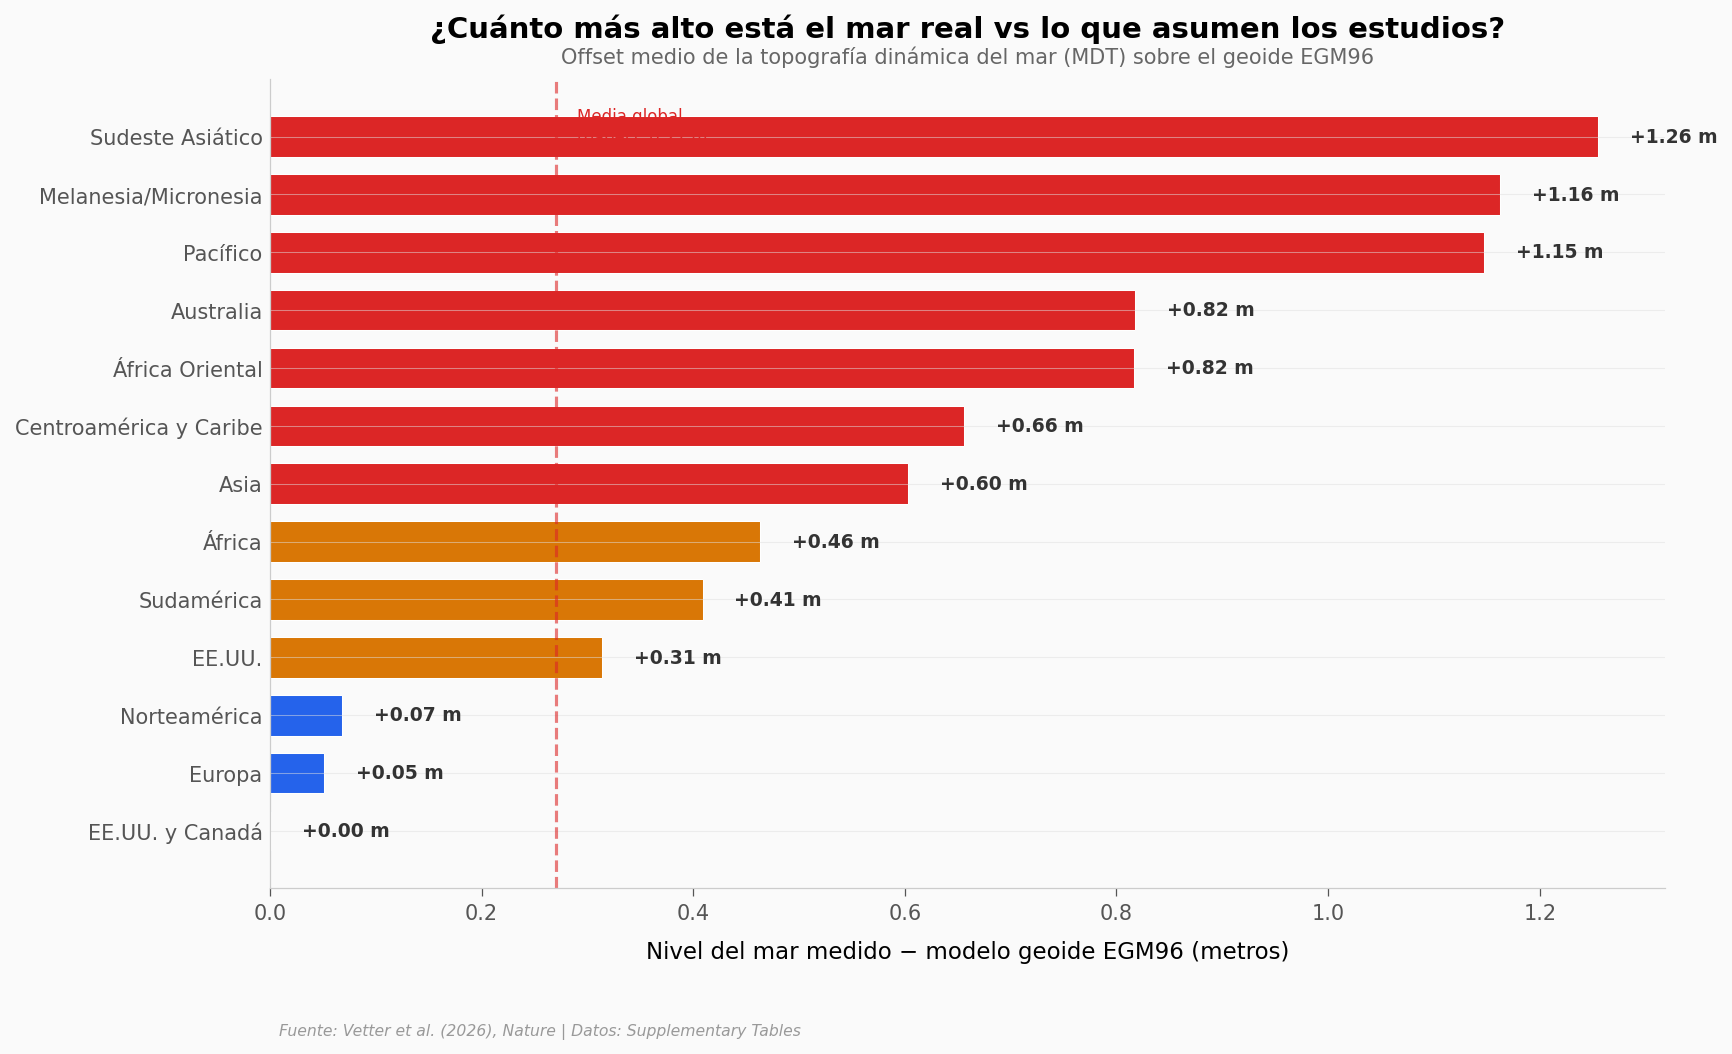

In [2]:
# ── Offset: nivel del mar medido vs modelo geoide (EGM96) ──
# Filtramos continentes principales + subregiones clave del Indo-Pacífico
regiones_hero = ['Southeast Asia', 'Melanesia, Micronesia, Polynesia', 'Pacific Region',
                 'Australia', 'East Africa', 'Central America, Carribean, northern South America',
                 'Africa', 'South America', 'Asia', 'USA',
                 'North America', 'Europe', 'USA, Canada']

df_hero = df_offset[df_offset['region'].isin(regiones_hero)].copy()
df_hero = df_hero.sort_values('mdt_egm96_mean', ascending=True)

# Nombres cortos para el eje Y
nombres = {
    'Southeast Asia': 'Sudeste Asiático',
    'Melanesia, Micronesia, Polynesia': 'Melanesia/Micronesia',
    'Pacific Region': 'Pacífico',
    'Australia': 'Australia',
    'East Africa': 'África Oriental',
    'Central America, Carribean, northern South America': 'Centroamérica y Caribe',
    'Africa': 'África',
    'South America': 'Sudamérica',
    'Asia': 'Asia',
    'USA': 'EE.UU.',
    'North America': 'Norteamérica',
    'Europe': 'Europa',
    'USA, Canada': 'EE.UU. y Canadá',
}
df_hero['nombre'] = df_hero['region'].map(nombres)

fig, ax = plt.subplots(figsize=(12, 7))

colors = [COLOR_ALERTA if v > 0.5 else (COLOR_REFERENCIA if v > 0.2 else COLOR_DATOS)
          for v in df_hero['mdt_egm96_mean']]

bars = ax.barh(range(len(df_hero)), df_hero['mdt_egm96_mean'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

# Inline values
for i, (val, name) in enumerate(zip(df_hero['mdt_egm96_mean'], df_hero['nombre'])):
    offset_x = 0.03 if val > 0 else -0.03
    ha = 'left' if val > 0 else 'right'
    ax.text(val + offset_x, i, f'+{val:.2f} m' if val > 0 else f'{val:.2f} m',
            va='center', ha=ha, fontsize=9, fontweight='bold',
            color='#333333')

ax.set_yticks(range(len(df_hero)))
ax.set_yticklabels(df_hero['nombre'], fontsize=10)
ax.axvline(x=0, color='#333333', linewidth=0.8, linestyle='-')
ax.axvline(x=OFFSET_PAPER, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(OFFSET_PAPER + 0.02, len(df_hero) - 0.5,
        f'Media global\n(paper): {OFFSET_PAPER} m',
        fontsize=8, color=COLOR_ALERTA, va='top')

ax.set_xlabel('Nivel del mar medido − modelo geoide EGM96 (metros)', fontsize=11)
ax.set_title('¿Cuánto más alto está el mar real vs lo que asumen los estudios?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Offset medio de la topografía dinámica del mar (MDT) sobre el geoide EGM96',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/offset_nivel_mar.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que revelan los datos

El Sudeste Asiático lidera el problema: el mar real está **+1,26 m por encima** de lo que asume el modelo EGM96. Melanesia y el Pacífico siguen con más de un metro de diferencia. En estas regiones, un estudio que use geoide en vez de mediciones reales está **subestimando la amenaza por más de un metro en promedio**.

Europa y Norteamérica apenas se desvían (+0,05 m), lo que explica por qué nadie lo vio: si trabajas con datos de Europa o Norteamérica, el error es mínimo (+0,05 m) — todo parece funcionar bien. Pero para el Indo-Pacífico — donde vive la mayoría de la población costera — el sesgo es enorme.

## ¿Cuánta gente se queda fuera?

Ese sesgo tiene consecuencias reales. Si el mar está más alto de lo que creen los modelos, hay más tierra bajo el agua y más personas en riesgo. Veamos cuántas más.

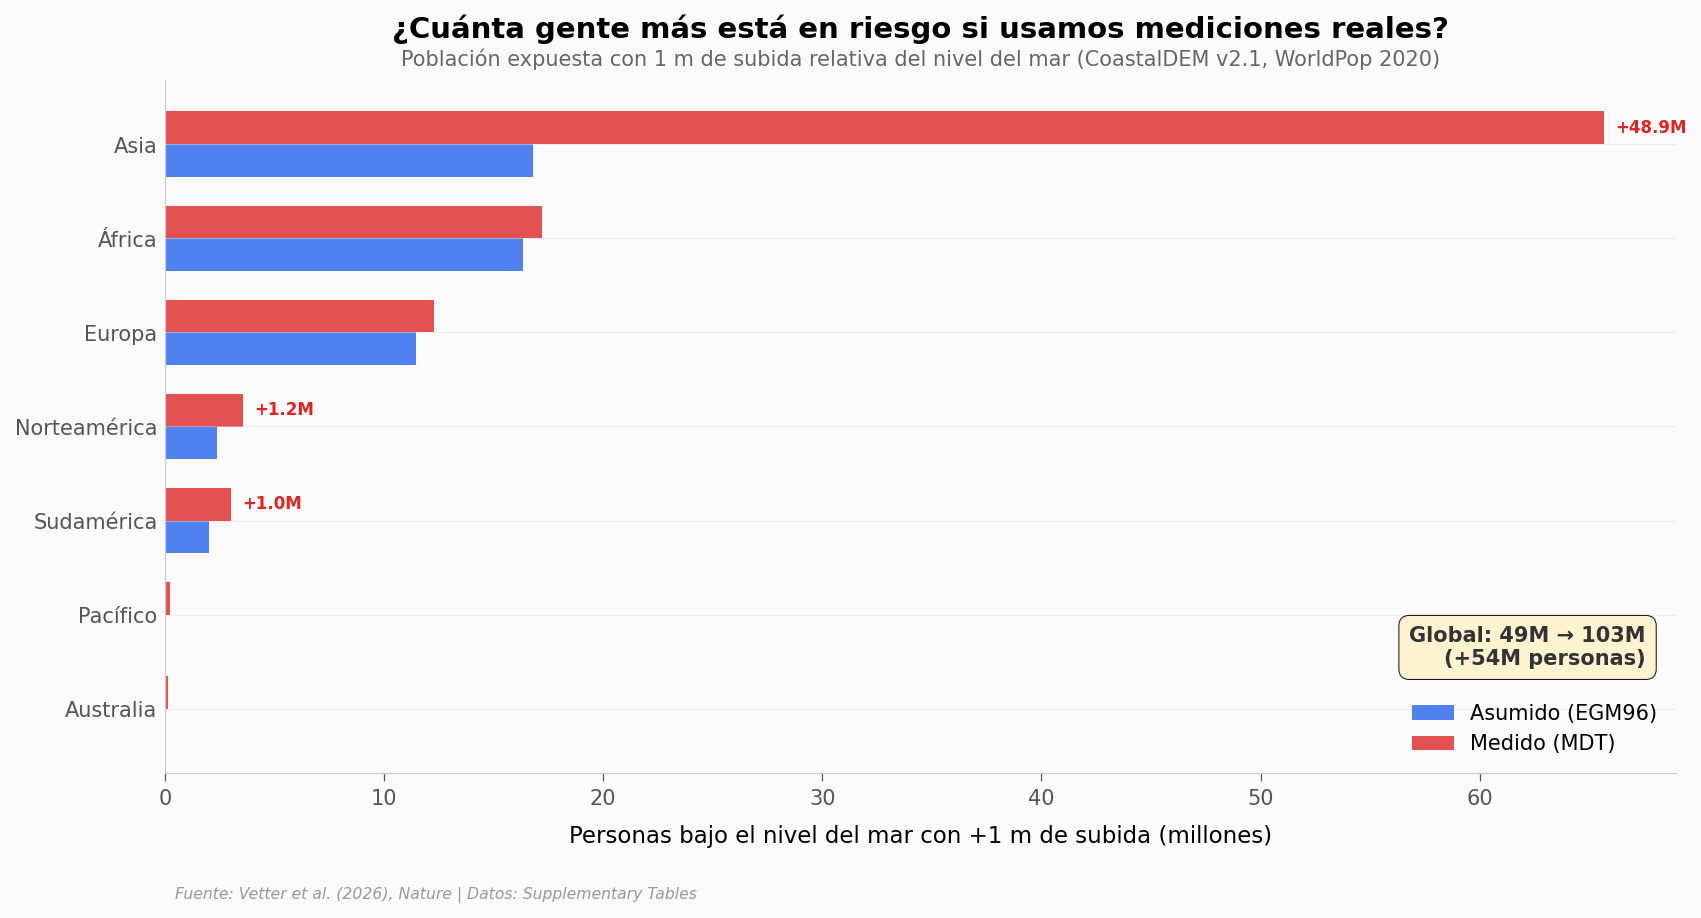

In [3]:
# ── Población en riesgo: geoide (EGM96) vs mediciones reales (MDT) ──
continentes = ['Africa', 'Asia', 'Europe', 'North America', 'South America',
               'Australia', 'Pacific Region']
df_cont = df_impacto[df_impacto['region'].isin(continentes)].copy()

nombres_cont = {
    'Africa': 'África', 'Asia': 'Asia', 'Europe': 'Europa',
    'North America': 'Norteamérica', 'South America': 'Sudamérica',
    'Australia': 'Australia', 'Pacific Region': 'Pacífico',
}
df_cont['nombre'] = df_cont['region'].map(nombres_cont)
df_cont = df_cont.sort_values('mdt_1m_pop_wp', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))

y = np.arange(len(df_cont))
h = 0.35

bars_egm = ax.barh(y - h/2, df_cont['egm96_1m_pop_wp'] / 1e6,
                    height=h, color=COLOR_DATOS, alpha=0.8, label='Asumido (EGM96)')
bars_mdt = ax.barh(y + h/2, df_cont['mdt_1m_pop_wp'] / 1e6,
                    height=h, color=COLOR_ALERTA, alpha=0.8, label='Medido (MDT)')

# Inline labels with difference
for i, (_, row) in enumerate(df_cont.iterrows()):
    egm = row['egm96_1m_pop_wp'] / 1e6
    mdt = row['mdt_1m_pop_wp'] / 1e6
    diff = mdt - egm
    if diff > 1:
        ax.text(mdt + 0.5, i + h/2, f'+{diff:.1f}M',
                fontsize=8, fontweight='bold', color=COLOR_ALERTA, va='center')

ax.set_yticks(y)
ax.set_yticklabels(df_cont['nombre'], fontsize=10)
ax.set_xlabel('Personas bajo el nivel del mar con +1 m de subida (millones)', fontsize=11)
ax.set_title('¿Cuánta gente más está en riesgo si usamos mediciones reales?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Población expuesta con 1 m de subida relativa del nivel del mar (CoastalDEM v2.1, WorldPop 2020)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='lower right')

# Global totals annotation
egm_total = df_impacto[df_impacto['region'] == 'Global']['egm96_1m_pop_wp'].values[0] / 1e6
mdt_total = df_impacto[df_impacto['region'] == 'Global']['mdt_1m_pop_wp'].values[0] / 1e6
ax.text(0.98, 0.15,
        f'Global: {egm_total:.0f}M → {mdt_total:.0f}M\n(+{mdt_total - egm_total:.0f}M personas)',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        color='#333333', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3CD', alpha=0.9))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/impacto_poblacion.png', dpi=200, bbox_inches='tight')
plt.show()

### Millones invisibles

Solo con CoastalDEM y WorldPop 2020, la diferencia es brutal: pasar de geoide a mediciones reales sube la estimación de 49 a 103 millones de personas bajo el nivel del mar con CoastalDEM y WorldPop 2020 (con +1 m de subida). Según el DEM y dataset poblacional, el rango va de 77M a 132M. Asia concentra la mayor diferencia absoluta.

Pero lo más inquietante es que esto **no es un problema nuevo** — y nadie lo corrigió. Veamos cuántos estudios manejaron correctamente los datos a lo largo de los años.

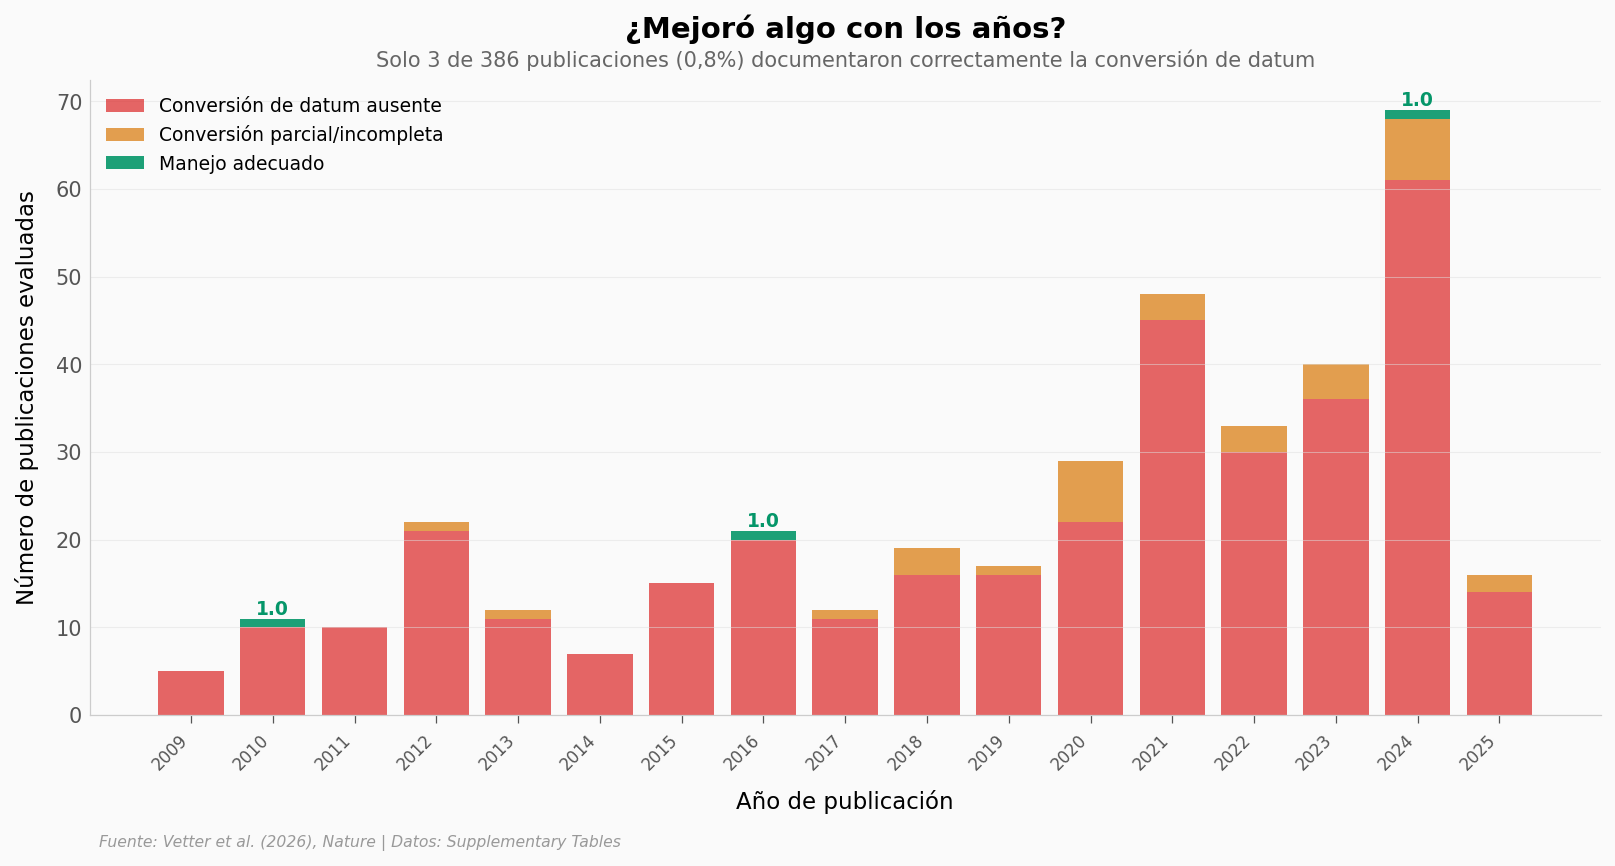

In [4]:
# ── Calidad de la literatura: documentación del datum vertical por año ──
df_year = df_lit.copy()
df_year['year'] = df_year['year'].astype(int)
df_year = df_year[(df_year['year'] >= 2009) & (df_year['year'] <= 2025)]

fig, ax = plt.subplots(figsize=(13, 5.5))

# Stacked bar: adecuados vs conv_ausente vs resto
df_year['resto'] = df_year['n_papers'] - df_year['conv_ausente'] - df_year['adecuados']

ax.bar(df_year['year'], df_year['conv_ausente'],
       color=COLOR_ALERTA, alpha=0.7, label='Conversión de datum ausente')
ax.bar(df_year['year'], df_year['resto'],
       bottom=df_year['conv_ausente'],
       color=COLOR_REFERENCIA, alpha=0.7, label='Conversión parcial/incompleta')
ax.bar(df_year['year'], df_year['adecuados'],
       bottom=df_year['conv_ausente'] + df_year['resto'],
       color=COLOR_SECUNDARIO, alpha=0.9, label='Manejo adecuado')

# Annotate the 3 adequate papers
for _, row in df_year[df_year['adecuados'] > 0].iterrows():
    ax.annotate(f"{row['adecuados']}", xy=(row['year'], row['n_papers']),
                fontsize=9, fontweight='bold', color=COLOR_SECUNDARIO,
                ha='center', va='bottom')

ax.set_xlabel('Año de publicación', fontsize=11)
ax.set_ylabel('Número de publicaciones evaluadas', fontsize=11)
ax.set_title('¿Mejoró algo con los años?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Solo 3 de {total_papers} publicaciones (0,8%) documentaron correctamente la conversión de datum',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper left')
ax.set_xticks(range(2009, 2026))
ax.set_xticklabels(range(2009, 2026), rotation=45, ha='right', fontsize=8)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/calidad_literatura.png', dpi=200, bbox_inches='tight')
plt.show()

### Un punto ciego comunitario

No hubo mejora. En 17 años (2009–2025), solo 3 publicaciones documentaron correctamente la conversión del datum vertical. El 90,7% ni siquiera la mencionó. Esto no es un error de un grupo — es un punto ciego de toda la comunidad.

¿Qué tan diferente sería la estimación dependiendo del modelo de elevación que se use?

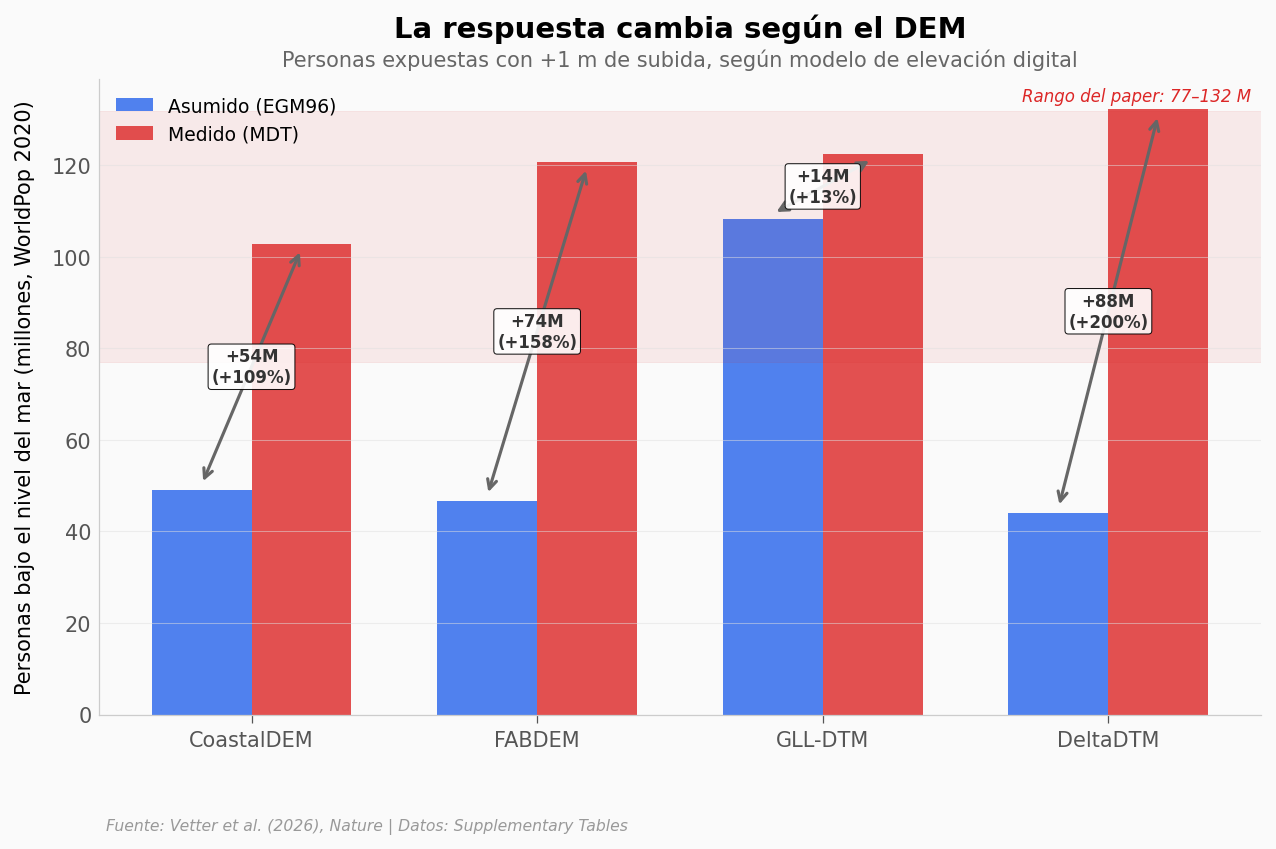


── Rango de estimaciones (MDT, WorldPop 2020) ──
  CoastalDEM      102.8 M
  FABDEM          120.7 M
  GLL-DTM         122.4 M
  DeltaDTM        132.2 M

Rango: 102.8M – 132.2M
Paper reporta: 77–132 M


In [5]:
# ── Rango de estimaciones según el DEM usado ──
global_dems = df_dem[df_dem['region'] == 'Global'].copy()

fig, ax = plt.subplots(figsize=(10, 5.5))

dems = global_dems['dem'].values
x = np.arange(len(dems))
w = 0.35

egm_wp = global_dems['egm96_1m_pop_wp'].values / 1e6
mdt_wp = global_dems['mdt_1m_pop_wp'].values / 1e6

bars1 = ax.bar(x - w/2, egm_wp, w, color=COLOR_DATOS, alpha=0.8, label='Asumido (EGM96)')
bars2 = ax.bar(x + w/2, mdt_wp, w, color=COLOR_ALERTA, alpha=0.8, label='Medido (MDT)')

# Flechas bidireccionales mostrando la diferencia
for i in range(len(dems)):
    mid_y = (egm_wp[i] + mdt_wp[i]) / 2
    diff = mdt_wp[i] - egm_wp[i]
    pct = (diff / egm_wp[i]) * 100
    ax.annotate('', xy=(x[i] + w/2, mdt_wp[i] - 1),
                xytext=(x[i] - w/2, egm_wp[i] + 1),
                arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
    ax.text(x[i], mid_y, f'+{diff:.0f}M\n(+{pct:.0f}%)',
            ha='center', va='center', fontsize=8, fontweight='bold', color='#333333',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

# Banda del paper (77-132M)
ax.axhspan(77, 132, color=COLOR_ALERTA, alpha=0.08)
ax.text(len(dems) - 0.5, 134, 'Rango del paper: 77–132 M',
        fontsize=8, color=COLOR_ALERTA, ha='right', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(dems, fontsize=10)
ax.set_ylabel('Personas bajo el nivel del mar (millones, WorldPop 2020)', fontsize=10)
ax.set_title('La respuesta cambia según el DEM',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Personas expuestas con +1 m de subida, según modelo de elevación digital',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/impacto_por_dem.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Resumen numérico ──
print("\n── Rango de estimaciones (MDT, WorldPop 2020) ──")
for _, row in global_dems.iterrows():
    print(f"  {row['dem']:15} {row['mdt_1m_pop_wp']/1e6:.1f} M")
print(f"\nRango: {mdt_wp.min():.1f}M – {mdt_wp.max():.1f}M")
print(f"Paper reporta: 77–132 M")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Más del 99% de estudios manejaron mal los datos | ✅ | 383/386 = 99,2%. Solo 3 papers con conversión correcta y documentación completa |
| El nivel del mar medido es más alto que el asumido | ✅ | Offset medio global: +0,22 m [0,91 m] (EGM96, supplementary). El paper reporta +0,27 m [0,76 m] — probablemente con un filtro costero más estrecho que reduce la varianza |
| Las mayores diferencias están en el Indo-Pacífico | ✅ | Sudeste Asiático: +1,26 m. Melanesia: +1,16 m. Europa: +0,05 m |
| 77–132 millones de personas bajo el nivel del mar | ✅ | Rango reproducido: 76,6M (GLL-DTM, LandScan) – 132,2M (DeltaDTM, WorldPop) |
| 31–37% más tierra y 48–68% más personas | ⚠️ | Nuestros datos (4 DEMs × 2 datasets de población = 8 combinaciones) muestran rangos de +12% a +211%. El paper reporta 31–37% (tierra) y 48–68% (personas), probablemente con un subconjunto específico de DEMs |
| 90% asumen nivel del mar basado en geoide | ✅ | 90,7% de papers no documentaron conversión del datum vertical |

> **Limitaciones:** (1) Los offsets del supplementary son promedios por región a 1.000 m de resolución; el paper puede usar un filtro costero más estrecho, lo que explica la discrepancia 0,22 m vs 0,27 m. (2) La estimación de población depende del DEM y del dataset poblacional — las combinaciones producen un rango amplio. (3) Las proyecciones de +1 m son **escenarios hipotéticos**, no predicciones temporales. (4) El paper sugiere que las discrepancias "pueden tener implicaciones" — no es una predicción causal de inundaciones.

## Ahora tú

1. **¿Qué pasa con menos subida?** Cambia `ESCENARIO_RSLR` a 0,5 o 0,3 m y recalcula el impacto. ¿Sigue siendo significativa la diferencia EGM96 vs MDT?
2. **Explora por país.** `df_impacto` tiene datos de regiones y subregiones. ¿Cuál es la región donde la corrección afecta a más personas en proporción a su población?
3. **¿Mejoró en 2024–2025?** Filtra `df_lit[df_lit['year'] >= 2024]`. ¿Hay señales de que la comunidad empezó a corregir el problema?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué región tiene la mayor discrepancia PROPORCIONAL entre EGM96 y MDT?

df_exp = df_impacto[~df_impacto['region'].isin(['Global', 'Antarctica'])].copy()
df_exp = df_exp[df_exp['egm96_1m_pop_wp'] > 0]

df_exp['diff_pct'] = ((df_exp['mdt_1m_pop_wp'] - df_exp['egm96_1m_pop_wp'])
                       / df_exp['egm96_1m_pop_wp'] * 100)

# Top 5 por discrepancia proporcional
top5 = df_exp.nlargest(5, 'diff_pct')[['region', 'egm96_1m_pop_wp', 'mdt_1m_pop_wp', 'diff_pct']]
print("Top 5 regiones por discrepancia proporcional (CoastalDEM, WorldPop):")
for _, row in top5.iterrows():
    print(f"  {row['region']:50} EGM96={row['egm96_1m_pop_wp']/1e6:.1f}M → MDT={row['mdt_1m_pop_wp']/1e6:.1f}M (+{row['diff_pct']:.0f}%)")

Top 5 regiones por discrepancia proporcional (CoastalDEM, WorldPop):
  Melanesia, Micronesia, Polynesia                   EGM96=0.0M → MDT=0.2M (+453%)
  Asia                                               EGM96=16.8M → MDT=65.7M (+291%)
  Vietnamese Mekong Delta                            EGM96=2.4M → MDT=9.4M (+290%)
  Southeast Asia                                     EGM96=8.3M → MDT=32.1M (+288%)
  Pacific Region                                     EGM96=0.1M → MDT=0.2M (+220%)


---

**Paper:** Vetter, T. et al. (2026). *Nature*. DOI: [10.1038/s41586-026-10196-1](https://doi.org/10.1038/s41586-026-10196-1)
**Datos:** Supplementary Tables (MOESM2–MOESM5) — distribución por continente, impacto por DEM, evaluación de literatura
**Licencia datos:** [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/)
**Código:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)